# 03MIAR - Algoritmos de optimización
## Actividad guiada 1

*Lautaro Medrano*

## Presentación

Profesor:
- Grupos A2, A3, B1, B2: David Álvarez Robles (dalvarezr@professor.universidadviu.com)

## Objetivos
- Comprender la utilidad y aplicar algoritmos divide y vencerás
- Comprender la utilidad y aplicar algoritmos voraces
- Comprender la utilidad y aplicar algoritmos de backtracking
- Realizar ejercicios avanzados -> Búsqueda de distancias mínimas (opcional)

## Divide y vencerás - Problema Torres de Hanói
- Parto de un problema y lo soluciono mediante la solución de subproblemas y unión de resultados
- En este caso concreto: H(n) = H(n-1) + 1 + H(n-1)
- Pensar lo anterior como... "Muevo todos los discos salvo uno a torre auxiliar, muevo el disco más grande a la torre final y muevo todos los discos restantes de la torre auxiliar a la final"
- Solamente resuelvo el problema de mover un disco (condición de parada de división) porque el resto se aplica el mismo algoritmo.
- Mover un disco es muy sencillo -> Solución directa -> Mover de torre de incio a torre de fin
- Ojo, el print del "if" es mover un disco entre torres (cualesquiera) y el print del "else" es el caso de mover el disco grande a torre final

In [109]:
# Imports al principio

import math
import random
import matplotlib.pyplot as plt

In [110]:
def torres_hannoi(numero_discos, inicio, fin):

    #print(f"torres_hannoi({numero_discos}, {inicio}, {fin})")

    # Si el número de discos es 1 -> Caso base, mover de inicio a fin
    if numero_discos == 1:
        #print(f"Caso base: Mover desde {inicio} a {fin} -- torres_hannoi({numero_discos}, {inicio}, {fin})")
        print(f"Mover desde {inicio} a {fin}")
    # Si el número de discos es mayor que 1 -> Mover resto de discos, mover disco único,
    # recuperar => Recursivamente
    else:
        torres_hannoi(numero_discos-1, inicio, 6-inicio-fin)
        #print(f"Caso central: Mover desde {inicio} a {fin} -- torres_hannoi({numero_discos}, {inicio}, {fin})")
        print(f"Mover desde {inicio} a {fin}")
        torres_hannoi(numero_discos-1, 6-inicio-fin, fin)

torres_hannoi(3,1,3)

Mover desde 1 a 3
Mover desde 1 a 2
Mover desde 3 a 2
Mover desde 1 a 3
Mover desde 2 a 1
Mover desde 2 a 3
Mover desde 1 a 3


In [111]:
def torres_hanoi(n, origen, destino, auxiliar):
    if n == 1:
        print(f"Mover disco 1 de {origen} a {destino}")
        return

    # Paso 1: Mover n-1 discos de origen a auxiliar usando destino
    torres_hanoi(n - 1, origen, auxiliar, destino)

    # Paso 2: Mover el disco n (el más grande) de origen a destino
    print(f"Mover disco {n} de {origen} a {destino}")

    # Paso 3: Mover n-1 discos de auxiliar a destino usando origen
    torres_hanoi(n - 1, auxiliar, destino, origen)


torres_hanoi(3, 'A', 'C', 'B')

Mover disco 1 de A a C
Mover disco 2 de A a B
Mover disco 1 de C a B
Mover disco 3 de A a C
Mover disco 1 de B a A
Mover disco 2 de B a C
Mover disco 1 de A a C


## Técnicas voraces - Problema del cambio
- Para resolver el problema, elijo una solución "buena" sin pensar en consecuencias
- Sería como elegir algo "óptimo" localmente con la esperanza de que sea lo mejor en general
- No siempre funciona bien -> Si en el conjunto de las soluciones, dos están próximas entre sí y generan una solución mayor puede fallar (ej: monedas [1, 3, 4, 9])

In [112]:
def cambio_monedas(sistema, cambio):

    print(f"Sistema: {sistema}")
    print(f"Cambio: {cambio}")

    # Inicialización de resultados
    resultado = [0] * len(sistema)

    # Para cada posible moneda, calculamos el número de monedas máximo que podemos dar
    # y lo restamos del cambio pendiente (mejor decisión local, que no tiene por qué
    # ser óptima
    for i in range(len(sistema)):
        total_monedas = cambio//sistema[i] # División con resultado entero
        resultado[i] = total_monedas
        cambio = cambio - resultado[i]*sistema[i]

    return resultado

# Sistema óptimo
sistema = [25, 10, 5, 1]
cambio = 27
resultado = cambio_monedas(sistema,cambio)
print(f"Resultado: {resultado}")

print("")

# Sistema NO óptimo
sistema = [11, 5, 1]
cambio = 15
resultado = cambio_monedas(sistema,cambio)
print(f"Resultado: {resultado}")

Sistema: [25, 10, 5, 1]
Cambio: 27
Resultado: [1, 0, 0, 2]

Sistema: [11, 5, 1]
Cambio: 15
Resultado: [1, 0, 4]


## Backtracking - Problema de las N reinas
- Se divide el problema en etapas
- En cada etapa se construye una solución parcial
- Se comprueba si esa solución parcial sigue siendo válida
- Si es válida, se continúa con la siguiente etapa
- Si no es válida, se descarta y se prueba otra alternativa
- Si ninguna alternativa funciona, se retrocede a la etapa anterior para cambiar decisiones

In [113]:
# Función que comprueba si por columnas hay un error en la solución
# etapa(i) = etapa (j) -> Error
# También comprueba si por diagonales hay un error en la solución
# (abs(i-j) = abs(xi-xj)) -> Error
def conflicto(solucion, etapa):
    for i in range(etapa+1):
        if solucion.count(solucion[i]) > 1:
            return True
        for j in range(etapa):
            if (i != j):
                if (abs(i-j) == abs(solucion[i]-solucion[j])):
                    return True
    else:
        return False

In [114]:
# Búsqueda de una solución
def colocar_reinas(numero_reinas, solucion = None, etapa = 0):

    if solucion is None:
        solucion = numero_reinas*[0]

    # Caso base: si he colocado todas las reinas (he completado todas las etapas)
    # etapa comienza en 0 y llega hasta numero_reinas
    if numero_reinas == etapa:
        #print(f"({numero_reinas}, {solucion}, {etapa})")
        print(f"{solucion}")
        return solucion

    else:
        # Recorro todas las columnas posibles para la reina en la fila (etapa)
        for i in range(1,numero_reinas+1):
            solucion[etapa] = i
            #print(f"({numero_reinas}, {solucion}, {etapa})")

            # Compruebo si la colocación actual no entra en conflicto
            # con reinas anteriores (columnas y diagonales)
            if not (conflicto(solucion, etapa)):
                # Si es válida, intento resolver el resto del tablero
                resultado = colocar_reinas(numero_reinas, solucion, etapa + 1)

                # Si desde aquí se encuentra una solución válida,
                # la propago hacia arriba para detener la búsqueda
                # En otras palabras, ya tengo resultado, no necesito
                # seguir probando, lo devuelvo
                if resultado is not None:
                    return resultado

        # Limpio la posición de la reina si todos los estados fallan (vuelta atrás)
        solucion[etapa] = 0

        # Si ninguna columna funciona en esta etapa, esta rama no tiene solución
        #return None

solucion = colocar_reinas(4)

[2, 4, 1, 3]


In [115]:
# Búsqueda de todas las soluciones
def colocar_reinas(numero_reinas, solucion = None, etapa = 0):

    if solucion is None:
        solucion = numero_reinas*[0]

    # Caso base: si he colocado todas las reinas (he completado todas las etapas)
    # etapa comienza en 0 y llega hasta numero_reinas
    if numero_reinas == etapa:
        #print(f"({numero_reinas}, {solucion}, {etapa})")
        print(f"{solucion}")

    else:
        # Recorro todas las columnas posibles para la reina en la fila (etapa)
        for i in range(1,numero_reinas+1):
            solucion[etapa] = i
            #print(f"({numero_reinas}, {solucion}, {etapa})")

            # Compruebo si la colocación actual no entra en conflicto
            # con reinas anteriores (columnas y diagonales)
            if not (conflicto(solucion, etapa)):
                # Si es válida, intento resolver el resto del tablero
                resultado = colocar_reinas(numero_reinas, solucion, etapa + 1)

                # Si desde aquí se encuentra una solución válida,
                # la propago hacia arriba para detener la búsqueda
                # En otras palabras, ya tengo resultado, no necesito
                # seguir probando, lo devuelvo
                #if resultado is not None:
                #    return resultado

        # Limpio la posición de la reina si todos los estados fallan (vuelta atrás)
        solucion[etapa] = 0

        # Si ninguna columna funciona en esta etapa, esta rama no tiene solución
        #return None

soluciones = colocar_reinas(4)

[2, 4, 1, 3]
[3, 1, 4, 2]


In [116]:
def es_prometedora(solucion,etapa):
    for i in range(etapa+1):
        if solucion.count(solucion[i]) > 1:
            return False
        for j in range(i+1,etapa+1):
            if abs(i-j)==abs(solucion[i]-solucion[j]):
                return False
    return True


def reinas(N,solucion=[],etapa=0):
    if len(solucion) == 0:
        solucion = [0 for i in range(N)]
    for i in range(1,N+1):
        solucion[etapa] = i
        if es_prometedora(solucion,etapa):
            if etapa == N-1:
                print(solucion)
            else:
                reinas(N,solucion,etapa+1)
        else:
            None

        solucion[etapa] = 0

reinas(4)

[2, 4, 1, 3]
[3, 1, 4, 2]


In [117]:
# Búsqueda de todas las soluciones
soluciones = colocar_reinas(8)

[1, 5, 8, 6, 3, 7, 2, 4]
[1, 6, 8, 3, 7, 4, 2, 5]
[1, 7, 4, 6, 8, 2, 5, 3]
[1, 7, 5, 8, 2, 4, 6, 3]
[2, 4, 6, 8, 3, 1, 7, 5]
[2, 5, 7, 1, 3, 8, 6, 4]
[2, 5, 7, 4, 1, 8, 6, 3]
[2, 6, 1, 7, 4, 8, 3, 5]
[2, 6, 8, 3, 1, 4, 7, 5]
[2, 7, 3, 6, 8, 5, 1, 4]
[2, 7, 5, 8, 1, 4, 6, 3]
[2, 8, 6, 1, 3, 5, 7, 4]
[3, 1, 7, 5, 8, 2, 4, 6]
[3, 5, 2, 8, 1, 7, 4, 6]
[3, 5, 2, 8, 6, 4, 7, 1]
[3, 5, 7, 1, 4, 2, 8, 6]
[3, 5, 8, 4, 1, 7, 2, 6]
[3, 6, 2, 5, 8, 1, 7, 4]
[3, 6, 2, 7, 1, 4, 8, 5]
[3, 6, 2, 7, 5, 1, 8, 4]
[3, 6, 4, 1, 8, 5, 7, 2]
[3, 6, 4, 2, 8, 5, 7, 1]
[3, 6, 8, 1, 4, 7, 5, 2]
[3, 6, 8, 1, 5, 7, 2, 4]
[3, 6, 8, 2, 4, 1, 7, 5]
[3, 7, 2, 8, 5, 1, 4, 6]
[3, 7, 2, 8, 6, 4, 1, 5]
[3, 8, 4, 7, 1, 6, 2, 5]
[4, 1, 5, 8, 2, 7, 3, 6]
[4, 1, 5, 8, 6, 3, 7, 2]
[4, 2, 5, 8, 6, 1, 3, 7]
[4, 2, 7, 3, 6, 8, 1, 5]
[4, 2, 7, 3, 6, 8, 5, 1]
[4, 2, 7, 5, 1, 8, 6, 3]
[4, 2, 8, 5, 7, 1, 3, 6]
[4, 2, 8, 6, 1, 3, 5, 7]
[4, 6, 1, 5, 2, 8, 3, 7]
[4, 6, 8, 2, 7, 1, 3, 5]
[4, 6, 8, 3, 1, 7, 5, 2]
[4, 7, 1, 8, 5, 2, 6, 3]


## Actividades extra

Problema: Encontrar los dos puntos más cercanos
- Dado un conjunto de puntos se trata de encontrar los dos puntos más cercanos

Guía para aprendizaje:
- Suponer en 1D, o sea, una lista de números: [3403, 4537, 9089, 9746, 7259, ….]
- Primer intento: Fuerza bruta
- Calcular la complejidad. ¿Se puede mejorar?
- Segundo intento. Aplicar Divide y Vencerás
- Calcular la complejidad. ¿Se puede mejorar?
- Extender el algoritmo a 2D: [(1122, 6175), (135, 4076), (7296, 2741)…]
- Extender el algoritmo a 3D.

### Fuerza Bruta


In [118]:
def closest_points_1D_brute_force(numbers):
    min_distance = math.inf
    closest_points = None

    # Comparo todos los puntos entre sí y me quedo con el par con menor distancia
    for i in range(len(numbers)):
        for j in range(i + 1, len(numbers)):
            distance = abs(numbers[i] - numbers[j])
            if distance < min_distance:
                min_distance = distance
                closest_points = (numbers[i], numbers[j])
    return closest_points

list = [3403, 4537, 9089, 9746, 7259]
print(f"Para la lista de números: {list}")
print(f"Los puntos más cercanos son: {closest_points_1D_brute_force(list)}")

list = [random.randint(1, 99999) for _ in range(0, 10)]
print(f"Para la lista de números: {list}")
print(f"Los puntos más cercanos son: {closest_points_1D_brute_force(list)}")


Para la lista de números: [3403, 4537, 9089, 9746, 7259]
Los puntos más cercanos son: (9089, 9746)
Para la lista de números: [44694, 52989, 75098, 54898, 67242, 82852, 12858, 19585, 50487, 64155]
Los puntos más cercanos son: (52989, 54898)


La complejidad del método de fuerza bruta es O(n^2) ya que incluye dos bucles anidados en función de n.

Otra forma de verlo es analizando la cantidad de operaciones del bucle interior (linea 7, en función de j):
- Cuando i vale 0, se ejecuta de 1 a n --> n - 1 veces
- Cuando i vale 1, se ejecuta de 2 a n --> n - 2 veces
...
- Cuando i vale n - 1 , se ejecuta de n - 1 a --> 1 vez

Esto se puede pensar como la famosa suma de Gauss (1 + 2 + ... + n - 1 ) = ((n - 1)^2 + (n - 1)) / 2, lo cual nos indica complejidad en función de n^2.

### Mejora

Una forma simple de mejorarlo es ordenar la lista antes de realizar las comparaciones. Esto nos dejará la complejidad en función de n.logn dado que el componente principal de la complejidad será el coste de ordenar la lista, el cual para la función built-in de sort de python es el mencionado n.logn

In [129]:
def closest_points_1D_sort(numbers):
    # Mejora que implica ordenar los números antes de compararlos para iterar en una sola vez.
    numbers.sort()

    min_distance = numbers[1] - numbers[0]
    closest_points = (numbers[0], numbers[1])

    for i in range(2, len(numbers)):
        if numbers[i] - numbers[i - 1] < min_distance:
            min_distance = numbers[i] - numbers[i - 1]
            closest_points = (numbers[i], numbers[i - 1])

    return closest_points

list = [3403, 4537, 9089, 9746, 7259]
print(f"Para la lista de números: {list}")
print(f"Los puntos más cercanos son: {closest_points_1D_sort(list)}")

list = [random.randint(1, 99999) for _ in range(0, 10)]
print(f"Para la lista de números: {list}")
print(f"Los puntos más cercanos son: {closest_points_1D_sort(list)}")

Para la lista de números: [3403, 4537, 9089, 9746, 7259]
Los puntos más cercanos son: (9746, 9089)
Para la lista de números: [34234, 53566, 93059, 26945, 81788, 79028, 43037, 66765, 58200, 4107]
Los puntos más cercanos son: (81788, 79028)


### Divide y vencerás

Se añade una implementación por Divide y vencerás por completitud (pedido del enunciado) aunque no aporta mejora a la solución anterior.

In [134]:
def closest_points_1D(numbers):
    closest_points = closest_points_1D_divide_and_conquer(sorted(numbers))
    print(f"Para la lista de números: {numbers}")
    print(f"Los puntos más cercanos son: {closest_points}")

def closest_points_1D_divide_and_conquer(numbers):
    if len(numbers) <= 2:
        return numbers

    half = len(numbers) // 2
    closest_points_left = closest_points_1D_divide_and_conquer(numbers[0:half])
    distance_left = closest_points_left[1] - closest_points_left[0] if len(closest_points_left) == 2 else math.inf

    closest_points_right = closest_points_1D_divide_and_conquer(numbers[half:len(numbers)])
    distance_right = closest_points_right[1] - closest_points_right[0] if len(closest_points_right) == 2 else math.inf

    if closest_points_right[0] - closest_points_left[-1] < min(distance_left, distance_right):
        return closest_points_left[-1], closest_points_right[0]
    elif distance_left < distance_right:
        return closest_points_left
    else:
        return closest_points_right

closest_points_1D([3403, 4537, 9089, 9746, 7259])
closest_points_1D([random.randint(1, 99999) for _ in range(0, 10)])

Para la lista de números: [3403, 4537, 9089, 9746, 7259]
Los puntos más cercanos son: [9089, 9746]
Para la lista de números: [32331, 71462, 45835, 73837, 9171, 75857, 65305, 82919, 58132, 38454]
Los puntos más cercanos son: (73837, 75857)


### 2D

Al pasar a 2D, se pierde la facilidad de comparar puntos iterando la lista, ya que la cercanía se mide en ambas dimensiones y cercanía en una sola no garantía cercanía total.

In [135]:
def calculate_distance_2d(p1, p2):
    return math.sqrt(
        (p1[0] - p2[0]) ** 2 +
        (p1[1] - p2[1]) ** 2
    )

def find_closest_points_2d_bf(points):
    closest_points = None

    for i in range(len(points) - 1):
        for j in range(i + 1, len(points)):
            if closest_points is None:
                closest_points = points[i], points[j]
            else:
                if calculate_distance_2d(points[i], points[j]) < calculate_distance_2d(closest_points[0], closest_points[1]):
                    closest_points = points[i], points[j]

    return closest_points

def find_closest_points_2d(points):
    if len(points) < 3:
        return find_closest_points_2d_bf(points)

    half = int(len(points) / 2)

    best_pair_left = find_closest_points_2d(points[0:half])
    best_pair_right = find_closest_points_2d(points[half:])

    if best_pair_left is None:
        best_pair = best_pair_right
    elif best_pair_right is None:
        best_pair = best_pair_left
    else:
        best_pair = best_pair_left \
            if calculate_distance_2d(*best_pair_left) < calculate_distance_2d(*best_pair_right) \
            else best_pair_right

    best_pair_distance = calculate_distance_2d(*best_pair)
    mid_strip = [p for p in points if abs(p[0] - points[half][0]) < best_pair_distance]

    best_pair_strip = find_closest_points_2d_bf(mid_strip)

    if best_pair_strip is None:
        return best_pair

    return best_pair \
        if best_pair_distance < calculate_distance_2d(*best_pair_strip) \
        else best_pair_strip

def closest_points_2d(points):
    points.sort()
    return find_closest_points_2d(points)

### Ejemplo de prueba 2D

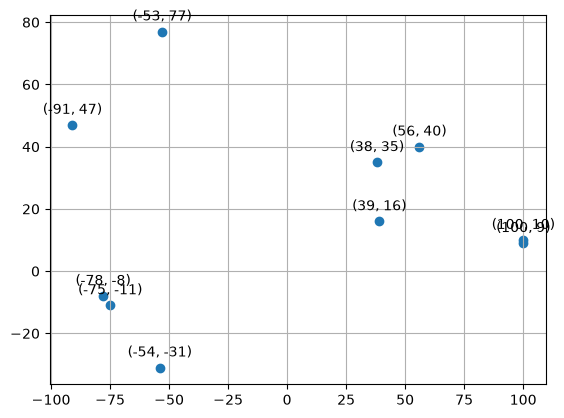

Los puntos más cercanos son: ((100, 9), (100, 10))
Con una distancia de: 1.0


In [137]:
points = []
for i in range(10):
    points.append((random.randint(-100, 100), random.randint(-100, 100)))

x, y = zip(*points)
plt.scatter(x, y)

for i in range(len(points)):
    xi, yi = points[i]
    plt.annotate(f'({xi}, {yi})', (xi, yi), textcoords="offset points", xytext=(0, 8), ha='center')

plt.grid(True)
plt.show()

closest_points = closest_points_2d(points)

print(f"Los puntos más cercanos son: {closest_points}")
print(f"Con una distancia de: {calculate_distance_2d(*closest_points)}")

### 3D

In [138]:
def calculate_distance_3d(p1, p2):
    return math.sqrt(
        (p1[0] - p2[0]) ** 2 +
        (p1[1] - p2[1]) ** 2 +
        (p1[2] - p2[2]) ** 2
    )

def find_closest_points_3d_bf(points):
    closest_points = None

    for i in range(len(points) - 1):
        for j in range(i + 1, len(points)):
            if closest_points is None:
                closest_points = points[i], points[j]
            else:
                if calculate_distance_3d(points[i], points[j]) < calculate_distance_3d(closest_points[0], closest_points[1]):
                    closest_points = points[i], points[j]

    return closest_points

def find_closest_points_strip_3d(points, min_distance):
    best_pair = None

    for i in range(len(points)):
        for j in range(i + 1, len(points)):
            if points[j][1] - points[i][1] >= min_distance:
                break

            if abs(points[j][2] - points[i][2]) >= min_distance:
                continue

            d_actual = calculate_distance_3d(points[i], points[j])

            if d_actual < min_distance:
                min_distance = d_actual
                best_pair = (points[i], points[j])

    return best_pair

def find_closest_points_3d(points):
    if len(points) < 3:
        return find_closest_points_3d_bf(points)

    half = int(len(points) / 2)

    best_pair_left = find_closest_points_3d(points[0:half])
    best_pair_right = find_closest_points_3d(points[half:])

    if best_pair_left is None:
        best_pair = best_pair_right
    elif best_pair_right is None:
        best_pair = best_pair_left
    else:
        best_pair = best_pair_left \
            if calculate_distance_3d(*best_pair_left) < calculate_distance_3d(*best_pair_right) \
            else best_pair_right

    best_pair_distance = calculate_distance_3d(*best_pair)

    mid_strip = [p for p in points if abs(p[0] - points[half][0]) < best_pair_distance]
    mid_strip.sort(key=lambda p: p[1])

    best_pair_strip = find_closest_points_strip_3d(mid_strip, best_pair_distance)

    if best_pair_strip is None:
        return best_pair

    return best_pair \
        if best_pair_distance < calculate_distance_3d(*best_pair_strip) \
        else best_pair_strip

def closest_points_3d(points):
    points.sort()
    return find_closest_points_3d(points)

### Ejemplo de prueba 3D

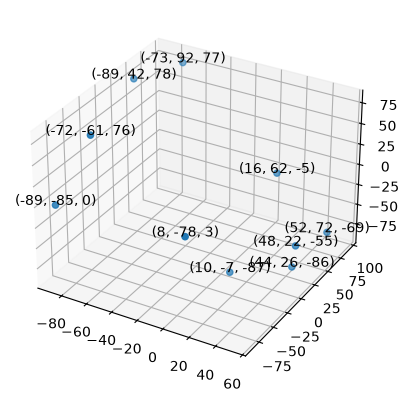

Los puntos más cercanos son: ((48, 22, -55), (44, 26, -86))
Con una distancia de: 5.656854249492381
Puntos encontrados por fuerza bruta: ((44, 26, -86), (48, 22, -55))


In [139]:
points = []
for i in range(10):
    points.append(
        (
            random.randint(-100, 100),
            random.randint(-100, 100),
            random.randint(-100, 100)
        )
    )

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

x, y, z = zip(*points)
ax.scatter(x, y, z)

for i in range(len(points)):
    xi, yi, zi = points[i]

    ax.text(xi, yi, zi + 0.15, f'({xi}, {yi}, {zi})', ha='center')

ax.grid(True)
plt.show()

closest_points = closest_points_3d(points)

print(f"Los puntos más cercanos son: {closest_points}")
print(f"Con una distancia de: {calculate_distance_2d(*closest_points)}")

print(f"Puntos encontrados por fuerza bruta: {find_closest_points_3d_bf(points)}")

## Fuentes utilizadas:
- https://sites.cs.ucsb.edu/~suri/cs235/ClosestPair.pdf
- https://www.geeksforgeeks.org/dsa/closest-pair-of-points-using-divide-and-conquer-algorithm/
- https://cs.stackexchange.com/questions/155286/closest-pair-of-points-in-3d